Class
0.0    55394
1.0      156
Name: count, dtype: int64

After SMOTE:
Class
0.0    44315
1.0    44315
Name: count, dtype: int64

Confusion Matrix:
[[11065    14]
 [    2    29]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     11079
         1.0       0.67      0.94      0.78        31

    accuracy                           1.00     11110
   macro avg       0.84      0.97      0.89     11110
weighted avg       1.00      1.00      1.00     11110

ROC-AUC: 0.9997204825170549

Top 10 Important Features:
V14     0.707152
V12     0.046776
V18     0.023377
Time    0.019675
V4      0.019110
V6      0.013723
V10     0.013369
V17     0.012530
V11     0.011649
V27     0.011269
dtype: float32


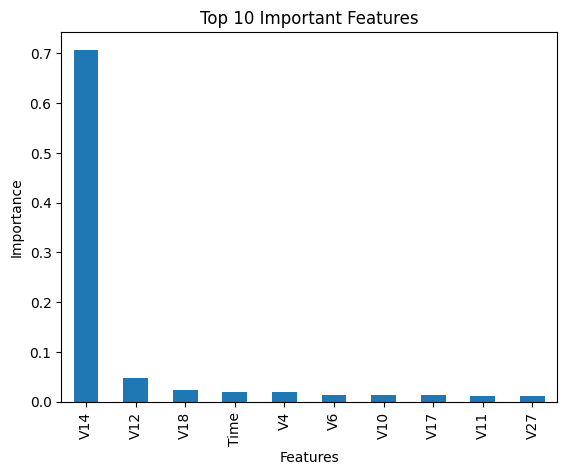

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier


# 1. Load dataset
df = pd.read_csv("creditcard.csv")


# 2. Clean dataset
df = df.dropna()


# 3. Separate input and output
X = df.drop("Class", axis=1)
y = df["Class"]


# 4. Check fraud and normal transactions
print(y.value_counts())


# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# 6. Balance training data using SMOTE
smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train.value_counts())


# 7. Create XGBoost model
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)


# 8. Train model
model.fit(X_train, y_train)


# 9. Get fraud probabilities
probability = model.predict_proba(X_test)[:, 1]


# 10. Tune decision threshold
threshold = 0.30

prediction = (probability >= threshold).astype(int)


# 11. Evaluate model
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, prediction))

print("\nClassification Report:")
print(classification_report(y_test, prediction))

print("ROC-AUC:", roc_auc_score(y_test, probability))


# 12. Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


print("\nTop 10 Important Features:")
print(importance.head(10))


# 13. Plot feature importance
importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()